# SIS
{func}`.SIS`

Perhaps the simplest epidemic model is a Susceptible-Infected-Susceptible (SIS) system, in which susceptible individuals may be infected and then do not have any immunity upon recovery.

There are 2 events:

- $S \rightarrow I$ at a rate, $\frac{\beta S I}{N}$
- $I \rightarrow S$ at a rate, $\gamma I$

We see how the set of ODEs evolve deterministically:

$$
\begin{aligned}
\frac{\mathrm{d}S}{\mathrm{d}t} &=  -\frac{\beta S I}{N} + \gamma I \\
\frac{\mathrm{d}I}{\mathrm{d}t} &=  \frac{\beta S I}{N} - \gamma I
\end{aligned}
$$

In [1]:
from pygom import common_models
import matplotlib.pyplot as plt
import numpy as np

n_pop = 1e4

model = common_models.SIS(
    {
        'beta': 0.5,
        'gamma': 0.2,
        'N': n_pop
    }
)

# Initial conditions
i0 = 10
x0 = [n_pop-i0, i0]

# Time range and increments
tmax = 50                               # maximum time over which to run solver
dt = 0.1                                # timestep for outputs
t = np.arange(0, tmax, dt)

model.initial_values = (x0, t[0])
solution = model.solve_deterministic(t)

After sufficiently long time, the system reaches an equilibrium state:

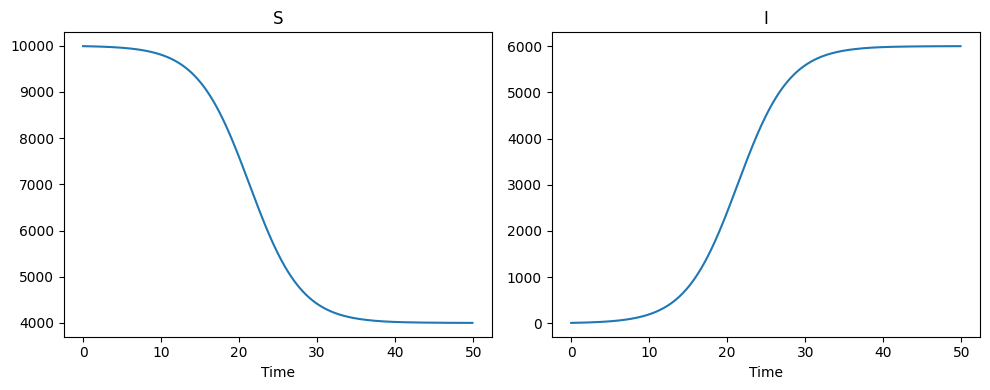

In [ ]:
state_names = model.state_list

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(state_names)):
    axes[i].plot(t, solution[0].result.y[:, i])
    axes[i].set_title(state_names[i])
    axes[i].set_xlabel('Time')

plt.tight_layout()
plt.show()